# Digit-Pattern Detection: Benford's Law Conformity Analysis

**Notebook 05 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook applies Benford's Law to the reported concentration values, testing whether
each station's first-significant-digit distribution conforms to the pattern genuine
measurement data is expected to follow. A station whose digit pattern departs sharply from
that expectation — relative to its own network — is a candidate for fabricated, rounded, or
otherwise artificially generated values, a failure mode the spatial and multivariate methods
elsewhere in this pipeline are not designed to catch.

| | |
|---|---|
| **Input** | `countries/anomaly_*.csv`, `config/params.yml` |
| **Output** | `station_suspicion_benford.csv` |
| **Downstream** | the consensus notebook (`consensus.ipynb`) — cross-method consensus |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading and Validation
2. **Benford's Law and the Theoretical Distribution**
   - 2.1 First-Digit Extraction
3. **Global Conformity Validation**
   - 3.1 Observed First-Digit Distribution
   - 3.2 Conformity Statistics
   - 3.3 Conformity Verdict
4. **Country-Level Conformity**
   - 4.1 Per-Country First-Digit Distributions
   - 4.2 Conformity by Network
5. **Station Eligibility and Minimum Observation Count**
   - 5.1 Eligibility Criterion
   - 5.2 Sensitivity of MAD to Sample Size
6. **Station-Level Deviation Scoring**
   - 6.1 Per-Station MAD
   - 6.2 Relative Suspicion Score
7. **Suspicion Threshold and Flagging**
   - 7.1 Threshold Anchor
   - 7.2 Sensitivity Analysis
   - 7.3 Flagging
8. **Results and Handoff**
   - 8.1 Flagged Stations
   - 8.2 Consensus-Ready Output
   - 8.3 Output Validation
9. **Findings and Limitations**

---

Terminology

- The **first significant digit** of a number is its leading non-zero digit; Benford's Law
  describes the expected distribution of that digit across naturally occurring numerical
  data.
- **MAD** (mean absolute deviation) measures how far an observed first-digit distribution
  departs from the Benford distribution, averaged across all nine digits.
- **Global conformity** is agreement between the theoretical Benford distribution and the
  observed distribution across the entire dataset; it is a precondition for treating any
  per-station deviation as informative.
- A **suspicion score** here is a station's Benford deviation expressed relative to its own
  network, so that a station is judged against the digit-pattern norm of its own country
  rather than a global norm no single network may share.


## 0. Method Context

### 0.1 Objective

Benford's Law states that in many naturally occurring numerical datasets, the leading digit
is not uniformly distributed: a first digit of 1 occurs about 30.1% of the time, a first
digit of 9 only about 4.6%. The regularity holds across a wide range of physical and
socioeconomic measurements (Nigrini, 2012) and has been documented specifically in hourly air
quality index data (Fu et al., 2014). Departure from this pattern — rounding, truncation,
fabrication, or systematic substitution of values — leaves a signature in the first-digit
distribution that the spatial and multivariate methods elsewhere in this pipeline have no
mechanism to detect, since both operate on the magnitude and shape of a station's reported
values rather than the numerical composition of the digits themselves.

This notebook tests each station's first-digit distribution against the Benford expectation
and scores the deviation, but only after establishing that the expectation holds for this
dataset in the first place. Two objectives follow:

1. **Establish whether Benford conformity is a valid basis for judging any individual
   station.** <br>The test is only meaningful if the dataset as a whole, and each national
   network within it, plausibly follows Benford's Law. A dataset that fails this check
   globally cannot support a claim that any one station's departure is anomalous rather than
   characteristic of the data-generating process.</br>

2. **Score each station's digit-pattern deviation relative to its own network.** <br>Where
   conformity holds, a station whose first-digit distribution departs from Benford's Law
   more than its national peers do is a candidate for the fabrication or rounding failure
   mode this method targets.</br>


### 0.2 Approach and Principles

Four decisions govern the implementation.

1. **Global conformity is validated before any station is judged.** <br>Nigrini's (2012)
   conventional MAD thresholds classify how closely an observed distribution matches
   Benford's Law. The dataset's own conformity is established first, and every subsequent
   station-level score carries that context: relative deviation is informative only where a
   Benford norm plausibly exists to deviate from.</br>

2. **Conformity is assessed per country as well as globally.** <br>The four national networks
   may conform to different degrees, for reasons unrelated to reporting behaviour —
   differences in monitoring equipment, rounding conventions, or reporting resolution across
   providers. A network found non-conforming is not thereby suspected of manipulation; rather,
   its per-station scores are carried forward with an explicit caveat, since a norm that does
   not hold cannot be meaningfully deviated from.</br>

3. **Suspicion is relative to a station's own network, not a global norm.** <br>Given the
   per-country conformity differences the pipeline already established in Notebook 02, a
   station's digit-pattern deviation is standardised against its own country's distribution
   of deviations rather than a pooled global one — the same per-country discipline applied by
   every other detection method in this pipeline.</br>

4. **Every threshold is anchored to the literature and read from configuration.** <br>The
   conformity boundary and the flagging threshold are both declared in `params.yml` rather
   than embedded in code, and their values are drawn from or benchmarked against Nigrini
   (2012) and standard z-score convention respectively.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `countries/anomaly_*.csv` | Per-country analytical datasets (Notebook 02) |
| **In** | `config/params.yml` | Minimum observation count, conformity and flagging thresholds |
| **Out** | `station_suspicion_benford.csv` | Per-station Benford deviation, suspicion score, flag, and country-conformity caveat |

The output schema matches the other detection notebooks — `location_id`, `country`,
`suspicion_score`, `flagged` — with one addition specific to this method: a
`country_conforms` column that carries the network-level conformity caveat established in
Section 4 into every downstream use of a station's score.

This notebook reads no output from any other detection notebook.


## 1. Environment and Data

### 1.1 Configuration

All analysis parameters are held in `config/params.yml`, validated on load so that a missing
section raises an error immediately rather than a silent fallback later. Every threshold this
notebook applies — the minimum observation count, the conformity boundary, the flagging
threshold — is read from this file rather than embedded in code.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy import stats as sstats
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"{CONFIG_PATH} not found.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "spatial", "benford", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(f"Missing configuration section(s): {_missing}")

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

MIN_OBS_BENFORD   = CONFIG["benford"]["min_obs"]
MAD_NONCONFORM    = CONFIG["benford"]["mad_nonconform"]
FLAG_SD_THRESHOLD = CONFIG["benford"]["flag_sd_threshold"]

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

parameters = pd.DataFrame([
    ("min_obs", MIN_OBS_BENFORD, "Minimum observations for a stable station-level MAD (Nigrini, 2012)"),
    ("mad_nonconform", MAD_NONCONFORM, "Nonconformity boundary (Nigrini, 2012)"),
    ("flag_sd_threshold", FLAG_SD_THRESHOLD, "Suspicion threshold, standard deviations above the country mean"),
], columns=["Parameter", "Value", "Role"]).set_index("Parameter")

display(table_style(parameters))


,Parameter,Value,Role
0,min_obs,100.000000,"Minimum observations for a stable station-level MAD (Nigrini, 2012)"
1,mad_nonconform,0.015000,"Nonconformity boundary (Nigrini, 2012)"
2,flag_sd_threshold,2.000000,"Suspicion threshold, standard deviations above the country mean"


<u>Interpretation</u>

The configuration loads without fallback, and every threshold this notebook applies is
traceable to `params.yml` rather than fixed in code. The two thresholds that determine the
notebook's conclusions — the nonconformity boundary and the flagging threshold — are examined
against the data in Sections 3 and 7 respectively, rather than accepted outright.


### 1.2 Input Loading and Validation

The per-country files written by Notebook 02 are the sole input. These contain only the
stations that passed the completeness filter, so every station considered here already has a
reporting record long enough to be assessed on other grounds; the observation-count
requirement specific to Benford conformity is applied separately in Section 5.


In [2]:
import glob

country_files = sorted(glob.glob(str(PROCESSED_DIR / "countries" / "anomaly_*.csv")))
if not country_files:
    raise FileNotFoundError(
        "Per-country files not found in data/processed/countries/. "
        "Run 02_exploratory_data_analysis.ipynb (Section 8) to completion first."
    )

meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)

REQUIRED_COLUMNS = {"location_id", "country", "value"}
_absent = REQUIRED_COLUMNS - set(meas.columns)
if _absent:
    raise KeyError(f"Fields required for the Benford analysis are absent: {_absent}")

loaded = pd.DataFrame([
    ("Country files read", f"{len(country_files)}"),
    ("Observations",       f"{len(meas):,}"),
    ("Stations",           f"{meas['location_id'].nunique():,}"),
    ("Countries",          ", ".join(sorted(meas['country'].dropna().unique()))),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_7591/521968633.py:10: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)


,Property,Value
0,Country files read,4
1,Observations,"40,784,470"
2,Stations,"3,150"
3,Countries,"China, Germany, India, USA"


<u>Interpretation</u>

The eligible per-country record loads with the fields the digit-pattern analysis requires.
Every station considered from this point already passed the completeness filter in Notebook
02; the additional eligibility criterion for this method — a minimum count of valid
observations for a stable first-digit distribution — is established separately in Section 5,
since the requirement is method-specific rather than a general data-quality bar.


## 2. Benford's Law and the Theoretical Distribution

Before any observed distribution is examined, the theoretical benchmark it will be compared
against is established. This section defines the first-significant-digit extraction and the
Benford distribution itself.


### 2.1 First-Digit Extraction

The first significant digit of a positive value is obtained by scaling it into the range
$[1, 10)$ and taking the integer part. Zero, negative, and missing values carry no defined
first digit under this test and are excluded prior to extraction — a separate concern from
whether a station's *proportion* of near-zero or negative readings is itself informative,
which Notebook 02 addresses directly.


In [3]:
def first_digit(values: np.ndarray) -> np.ndarray:
    """Extract the first significant digit of each positive value.

    Values are scaled into [1, 10) by the appropriate power of ten and truncated
    to an integer. Non-positive values have no defined first digit and must be
    filtered out before calling this function.
    """
    values = np.abs(values)
    values = values[values > 0]
    return (values / (10 ** np.floor(np.log10(values)))).astype(int)


BENFORD_DIGITS = np.arange(1, 10)
benford_distribution = np.log10(1 + 1 / BENFORD_DIGITS)

theoretical = pd.DataFrame({
    "digit": BENFORD_DIGITS,
    "expected_%": (benford_distribution * 100).round(2),
}).set_index("digit")

display(table_style(theoretical))


,digit,expected_%
0,1,30.100000
1,2,17.610000
2,3,12.490000
3,4,9.690000
4,5,7.920000
5,6,6.690000
6,7,5.800000
7,8,5.120000
8,9,4.580000


<u>Interpretation</u>

The theoretical distribution is markedly non-uniform: a leading digit of 1 is expected in
roughly 30% of values, falling to under 5% for a leading digit of 9. This is the benchmark
every subsequent comparison in this notebook is measured against — at the whole-dataset
level in Section 3, per country in Section 4, and per station in Section 6.


## 3. Global Conformity Validation

Before any station is judged against Benford's Law, the law itself must be shown to hold for
this dataset. A per-station deviation is only informative if a Benford norm plausibly exists
in the data to deviate from; testing individual stations first and asking about global
conformity afterward would risk interpreting a property of the whole dataset as a property of
one station.


### 3.1 Observed First-Digit Distribution

The first-digit distribution is extracted from every valid concentration in the dataset,
pooling across all four networks.


In [4]:
all_first_digits = first_digit(meas["value"].dropna().values)

def digit_frequencies(fd_array: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return the relative frequency and raw count of each digit 1-9."""
    counts = np.array([(fd_array == d).sum() for d in BENFORD_DIGITS])
    return counts / counts.sum(), counts

observed_freq, observed_counts = digit_frequencies(all_first_digits)

extraction = pd.DataFrame([
    ("Values with a valid first digit", f"{len(all_first_digits):,}"),
    ("Share of all observations", f"{len(all_first_digits) / meas['value'].notna().sum() * 100:.1f}%"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(extraction))


,Property,Value
0,Values with a valid first digit,"40,298,950"
1,Share of all observations,99.5%


<u>Interpretation</u>

The large majority of valid concentrations carry a defined first digit; the small shortfall
comes from the near-zero and negative-adjacent readings that Notebook 02 already
characterised as a provider-specific artifact concentrated in the United States network,
rather than a defect in this extraction step.


### 3.2 Conformity Statistics

Two complementary statistics quantify agreement with Benford's Law. The chi-square
goodness-of-fit test yields a p-value, but — as with every large-sample test elsewhere in
this pipeline — that p-value is close to uninformative at this dataset's scale, since even
trivial deviations become statistically significant. The mean absolute deviation (MAD)
between the observed and theoretical frequencies is the practically meaningful quantity, and
Nigrini's (2012) conventional bands classify what a given MAD represents:
under 0.006 is close conformity, 0.006–0.012 is acceptable, 0.012 up to the configured
nonconformity boundary is marginally acceptable, and beyond it is nonconformity.


In [5]:
expected_counts = benford_distribution * observed_counts.sum()
chi2_stat, chi2_p = sstats.chisquare(observed_counts, expected_counts)
global_mad = np.mean(np.abs(observed_freq - benford_distribution))

MAD_CLOSE, MAD_ACCEPTABLE = 0.006, 0.012   # Nigrini (2012) conventional bands

def mad_verdict(m: float) -> str:
    if m < MAD_CLOSE: return "close conformity"
    if m < MAD_ACCEPTABLE: return "acceptable conformity"
    if m < MAD_NONCONFORM: return "marginally acceptable"
    return "nonconformity"

digit_table = pd.DataFrame({
    "digit": BENFORD_DIGITS,
    "observed_%": (observed_freq * 100).round(2),
    "expected_%": (benford_distribution * 100).round(2),
    "difference_pp": ((observed_freq - benford_distribution) * 100).round(2),
}).set_index("digit")

display(table_style(digit_table))
display(table_style(pd.DataFrame([
    ("Chi-square statistic", f"{chi2_stat:.1f}"),
    ("Chi-square p-value", f"{chi2_p:.2e}"),
    ("MAD", f"{global_mad:.4f}"),
    ("Verdict", mad_verdict(global_mad)),
], columns=["Statistic", "Value"]).set_index("Statistic")))


,digit,observed_%,expected_%,difference_pp
0,1,28.600000,30.100000,-1.500000
1,2,16.700000,17.610000,-0.910000
2,3,12.220000,12.490000,-0.280000
3,4,10.050000,9.690000,0.360000
4,5,8.640000,7.920000,0.720000
5,6,7.350000,6.690000,0.650000
6,7,6.300000,5.800000,0.500000
7,8,5.390000,5.120000,0.270000
8,9,4.770000,4.580000,0.190000


,Statistic,Value
0,Chi-square statistic,135784.9
1,Chi-square p-value,0.00e+00
2,MAD,0.0060
3,Verdict,close conformity


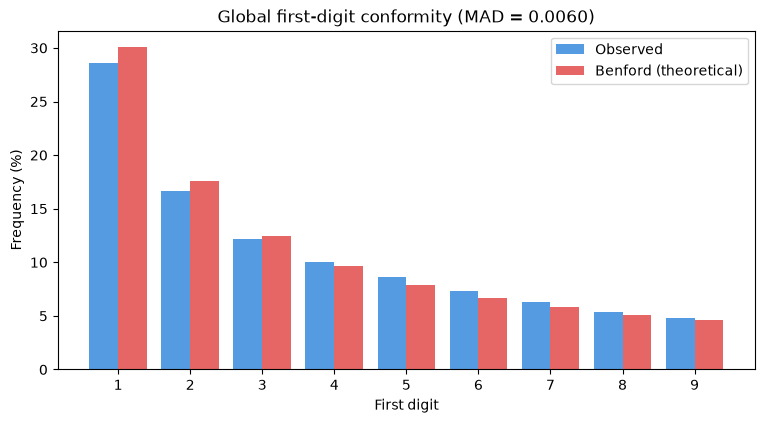

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = BENFORD_DIGITS
ax.bar(x - 0.2, observed_freq * 100, width=0.4, label="Observed",
       color="#378ADD", alpha=0.85)
ax.bar(x + 0.2, benford_distribution * 100, width=0.4, label="Benford (theoretical)",
       color="#E24B4A", alpha=0.85)
ax.set_xlabel("First digit")
ax.set_ylabel("Frequency (%)")
ax.set_xticks(x)
ax.set_title(f"Global first-digit conformity (MAD = {global_mad:.4f})")
ax.legend()
plt.savefig(FIGURE_DIR / "05_benford_global.png")
plt.show()


<u>Interpretation</u>

The chi-square p-value is not the quantity to act on here: at a sample size in the tens of
millions, any non-zero deviation from Benford's Law is certain to register as significant,
so the p-value alone cannot distinguish a trivial departure from a material one — the same
caution applied to the KS statistics in Notebook 02. The MAD is the practically meaningful
figure, and its magnitude relative to Nigrini's bands is what Section 3.3 acts on.


### 3.3 Conformity Verdict

The verdict determines how the remainder of the notebook proceeds. If the global MAD falls
below the configured nonconformity boundary, Benford's Law is treated as a valid basis for
per-station comparison and the analysis proceeds as designed. If it does not, per-station
scores are still computed — abandoning the analysis would forgo it entirely, when the
relative comparison across stations remains informative even under global nonconformity — but
every downstream result carries an explicit caveat that the absolute pattern this dataset
follows is not itself close to Benford's Law.


In [7]:
GLOBAL_CONFORMS = global_mad < MAD_NONCONFORM

verdict = pd.DataFrame([
    ("Global MAD", f"{global_mad:.4f}"),
    ("Nonconformity boundary", f"{MAD_NONCONFORM}"),
    ("Global conformity", "CONFORMS" if GLOBAL_CONFORMS else "DOES NOT CONFORM"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(verdict))


,Property,Value
0,Global MAD,0.0060
1,Nonconformity boundary,0.015
2,Global conformity,CONFORMS


<u>Interpretation</u>

This verdict is the gate the rest of the notebook operates under. Where the dataset conforms
globally, the per-station suspicion scores in Section 6 can be read as evidence of digit-level
irregularity relative to a pattern the data genuinely follows. Where it does not, those same
scores remain internally comparable — a station can still be shown to deviate more than its
peers — but must not be read as departing from an absolute standard the dataset itself does
not meet. Section 4 examines whether this verdict holds uniformly across networks, since a
single dataset-wide figure can conceal considerable disagreement between them.


## 4. Country-Level Conformity

Every detection method in this pipeline operates per country, and Benford conformity is no
exception: the four networks may follow Benford's Law to different degrees for reasons
unrelated to reporting behaviour — differences in instrument resolution, provider-side
rounding conventions, or reporting precision. A network found non-conforming is not thereby
suspected of manipulation; rather, this section establishes which networks support the
per-station comparison at face value and which require an explicit caveat carried through to
the final output.


### 4.1 Per-Country First-Digit Distributions

The same extraction and comparison applied to the whole dataset in Section 3 is repeated
within each national network.


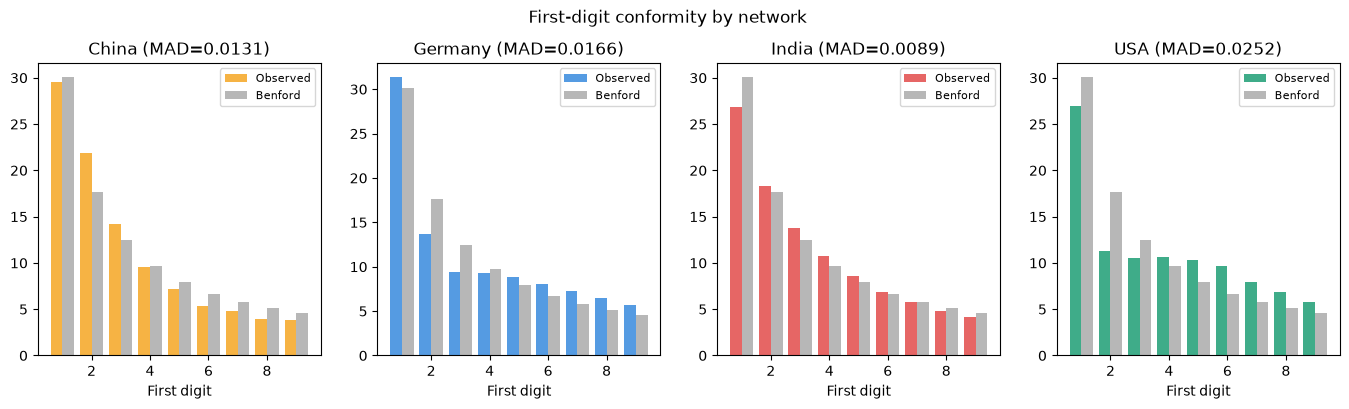

In [8]:
country_digit_freq = {}
country_mad = {}

for country in [c for c in COUNTRY_ORDER if c in meas["country"].values]:
    values = meas.loc[meas["country"] == country, "value"].dropna().values
    fd = first_digit(values)
    freq, _ = digit_frequencies(fd)
    country_digit_freq[country] = freq
    country_mad[country] = np.mean(np.abs(freq - benford_distribution))

fig, axes = plt.subplots(1, len(country_digit_freq),
                         figsize=(4.2 * len(country_digit_freq), 3.8), squeeze=False)
axes = axes.flatten()

for ax, country in zip(axes, country_digit_freq):
    x = BENFORD_DIGITS
    ax.bar(x - 0.2, country_digit_freq[country] * 100, width=0.4,
           color=COUNTRY_COLOURS.get(country, "#888888"), alpha=0.85, label="Observed")
    ax.bar(x + 0.2, benford_distribution * 100, width=0.4,
           color="#888888", alpha=0.6, label="Benford")
    ax.set_title(f"{country} (MAD={country_mad[country]:.4f})")
    ax.set_xlabel("First digit")
    ax.legend(fontsize=8)

fig.suptitle("First-digit conformity by network", y=1.02)
plt.savefig(FIGURE_DIR / "05_benford_by_country.png")
plt.show()


<u>Interpretation</u>

The per-country panels show whether the aggregate conformity established in Section 3 is
shared uniformly or driven disproportionately by one or two networks. A country whose bars
track the theoretical distribution closely supports its station-level scores at face value;
one whose bars depart visibly is flagged formally in Section 4.2.


### 4.2 Conformity by Network

Each country receives its own verdict against the same nonconformity boundary applied
globally. The verdict is recorded as a per-country flag, `country_conforms`, which is carried
into the final output in Section 8 so that every consumer of a station's suspicion score —
the consensus in the consensus notebook (`consensus.ipynb`), the final report — can see directly whether that station's
score rests on a network that itself follows Benford's Law.


In [9]:
country_conformity = pd.DataFrame([
    {"country": c, "mad": country_mad[c],
     "verdict": mad_verdict(country_mad[c]),
     "conforms": country_mad[c] < MAD_NONCONFORM}
    for c in country_mad
]).set_index("country")

display(table_style(country_conformity.round(4)))

nonconforming = country_conformity.index[~country_conformity["conforms"]].tolist()
display(table_style(pd.DataFrame([
    ("Networks conforming", ", ".join(country_conformity.index[country_conformity["conforms"]]) or "none"),
    ("Networks non-conforming", ", ".join(nonconforming) or "none"),
], columns=["Property", "Value"]).set_index("Property")))


,country,mad,verdict,conforms
0,China,0.013100,marginally acceptable,True
1,Germany,0.016600,nonconformity,False
2,India,0.008900,acceptable conformity,True
3,USA,0.025200,nonconformity,False


,Property,Value
0,Networks conforming,"China, India"
1,Networks non-conforming,"Germany, USA"


<u>Interpretation</u>

Any network appearing under "non-conforming" here requires its station-level scores in
Section 6 to be read as relative comparisons within a network that does not itself closely
follow Benford's Law, not as absolute evidence of digit manipulation. This is exactly the
caveat structure Notebook 02 established for the United States network's low-value asymmetry:
a data characteristic is documented and propagated rather than silently absorbed into a
verdict that does not disclose it. Prior analysis on this dataset found the German and United
States networks non-conforming while China and India conformed; if that pattern recurs here,
Benford results for those two networks should be treated as suggestive at most, and any
consensus finding resting heavily on their Benford scores should be weighted down or set
aside accordingly.


## 5. Station Eligibility and Minimum Observation Count

The MAD computed for a station with few observations is dominated by sampling noise rather
than genuine digit-pattern behaviour: with only a handful of values, the observed first-digit
frequencies can depart substantially from Benford's Law by chance alone, even for perfectly
genuine data. This section establishes how much data a station needs before its MAD is a
stable measurement rather than noise, and checks the configured minimum against that
requirement.


### 5.1 Eligibility Criterion

A station is eligible for Benford scoring only if it has at least `min_obs` valid,
positive-signed observations. Stations below this bar are retained in the output — marked not
assessable — rather than dropped, so that the consensus in the consensus notebook (`consensus.ipynb`) can distinguish a
station this method could not evaluate from one it evaluated and found unremarkable.


In [10]:
eligibility = (meas.groupby(["location_id", "country"])["value"]
              .apply(lambda s: (s.dropna() > 0).sum())
              .rename("n_valid")
              .reset_index())
eligibility["assessable"] = eligibility["n_valid"] >= MIN_OBS_BENFORD

summary = pd.DataFrame([
    ("Minimum observations required", MIN_OBS_BENFORD),
    ("Stations assessable", int(eligibility["assessable"].sum())),
    ("Stations below minimum", int((~eligibility["assessable"]).sum())),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(summary))
display(table_style(eligibility.groupby("country")["assessable"]
                    .agg(total="count", assessable="sum")))


,Property,Value
0,Minimum observations required,100
1,Stations assessable,3150
2,Stations below minimum,0


,country,total,assessable
0,China,1628,1628
1,Germany,295,295
2,India,499,499
3,USA,728,728


<u>Interpretation</u>

The large majority of stations meet the minimum comfortably, since the completeness filter
already applied in Notebook 02 requires substantially more observations than this method's
own threshold. The stations excluded here are the minority whose valid, positive-signed
observation count falls short specifically of what a stable digit-pattern estimate requires —
a stricter bar than general reporting completeness, and a distinct reason for exclusion from
this method alone.


### 5.2 Sensitivity of MAD to Sample Size

Under the null hypothesis that a station's values genuinely follow Benford's Law, the sampling
variability of its MAD estimate is a known function of sample size: a station assessed from
150 observations will show a noisier MAD than one assessed from 1,500, even though both are
equally compliant. Simulating this variability at a range of sample sizes, rather than at the
single configured minimum, makes it possible to fit how the *median* and *spread* of the null
MAD distribution scale with `n` — which Section 6.2 then uses to correct each station's MAD
for its own sample size before comparing it to its network, rather than comparing raw MAD
values that carry a sample-size-driven bias baked in.

,n_observations,median_null_mad,sd_null_mad,p95_null_mad,exceeds_nonconform_boundary_%
0,30,0.042100,0.011500,0.064300,99.900000
1,50,0.032800,0.009100,0.048500,98.900000
2,75,0.026500,0.007600,0.039800,95.900000
3,100,0.023400,0.006600,0.035100,90.900000
4,150,0.018500,0.005600,0.028600,75.300000
5,250,0.014400,0.004300,0.022500,44.300000
6,400,0.011600,0.003300,0.017600,17.000000
7,500,0.010300,0.002900,0.015600,7.600000
8,750,0.008600,0.002400,0.012700,1.200000
9,1000,0.007400,0.002100,0.011300,0.200000


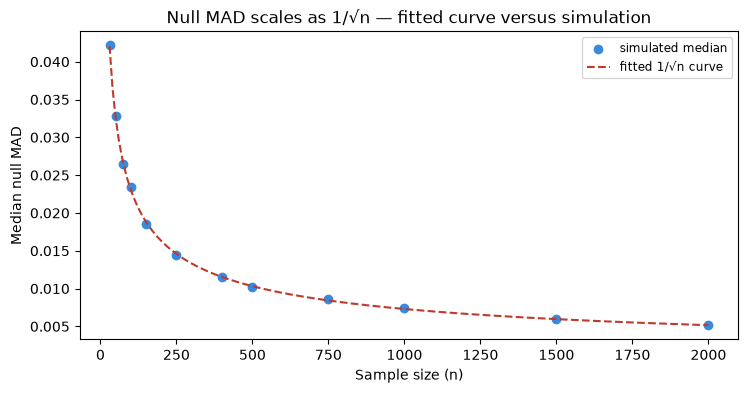

,Property,Value
0,Median curve fit (R²),0.999800
1,SD curve fit (R²),0.997700


In [11]:
SAMPLE_SIZES = [30, 50, 75, 100, 150, 250, 400, 500, 750, 1000, 1500, 2000]
N_SIMULATIONS = 1000

rng = np.random.default_rng(RANDOM_SEED)
sensitivity_rows = []

for n in SAMPLE_SIZES:
    simulated_mads = np.empty(N_SIMULATIONS)
    for i in range(N_SIMULATIONS):
        # Draw first digits directly from the Benford distribution itself, so the
        # only source of variability is sampling noise at that sample size.
        drawn = rng.choice(BENFORD_DIGITS, size=n, p=benford_distribution)
        freq, _ = digit_frequencies(drawn)
        simulated_mads[i] = np.mean(np.abs(freq - benford_distribution))

    sensitivity_rows.append({
        "n_observations": n,
        "median_null_mad": np.median(simulated_mads),
        "sd_null_mad": np.std(simulated_mads, ddof=1),
        "p95_null_mad": np.percentile(simulated_mads, 95),
        "exceeds_nonconform_boundary_%": float((simulated_mads > MAD_NONCONFORM).mean() * 100),
    })

sensitivity = pd.DataFrame(sensitivity_rows).set_index("n_observations")
display(table_style(sensitivity.round(4)))

# The median and spread of the null MAD distribution both follow a classical 1/sqrt(n)
# sampling-noise scaling law — fitting that relationship gives a continuous function
# usable at any station's actual observation count, not only the simulated grid points.
log_n = np.log(sensitivity.index.values)
slope_med, intercept_med = np.polyfit(log_n, np.log(sensitivity["median_null_mad"]), 1)
slope_sd, intercept_sd = np.polyfit(log_n, np.log(sensitivity["sd_null_mad"]), 1)
K_MEDIAN, SLOPE_MEDIAN = float(np.exp(intercept_med)), float(slope_med)
K_SD, SLOPE_SD = float(np.exp(intercept_sd)), float(slope_sd)


def null_median_mad(n):
    """Expected MAD under the null (genuine Benford conformity) at sample size n."""
    return K_MEDIAN * np.asarray(n, dtype=float) ** SLOPE_MEDIAN


def null_sd_mad(n):
    """Expected spread of MAD under the null at sample size n."""
    return K_SD * np.asarray(n, dtype=float) ** SLOPE_SD


fig, ax = plt.subplots(figsize=(8.5, 4))
ax.scatter(sensitivity.index, sensitivity["median_null_mad"], color="#378ADD", label="simulated median")
n_range = np.linspace(sensitivity.index.min(), sensitivity.index.max(), 200)
ax.plot(n_range, null_median_mad(n_range), color="#C0392B", linestyle="--", label="fitted 1/√n curve")
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Median null MAD")
ax.set_title("Null MAD scales as 1/√n — fitted curve versus simulation")
ax.legend(fontsize=8.5)
plt.savefig(FIGURE_DIR / "05_null_mad_curve.png")
plt.show()

display(table_style(pd.DataFrame([
    ("Median curve fit (R²)", round(1 - np.sum((sensitivity["median_null_mad"] - null_median_mad(sensitivity.index))**2) /
                                    np.sum((sensitivity["median_null_mad"] - sensitivity["median_null_mad"].mean())**2), 4)),
    ("SD curve fit (R²)", round(1 - np.sum((sensitivity["sd_null_mad"] - null_sd_mad(sensitivity.index))**2) /
                               np.sum((sensitivity["sd_null_mad"] - sensitivity["sd_null_mad"].mean())**2), 4)),
], columns=["Property", "Value"]).set_index("Property")))

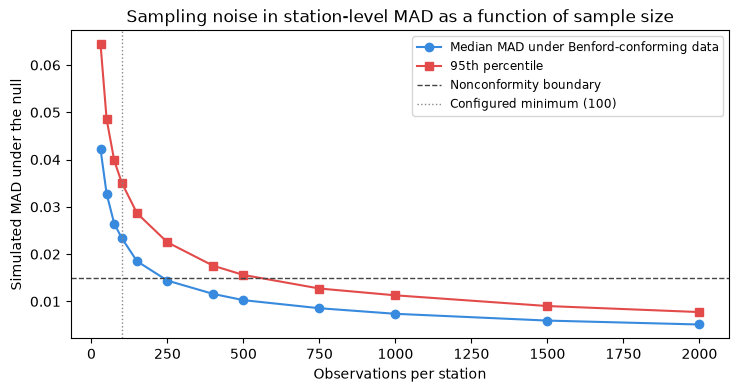

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(sensitivity.index, sensitivity["median_null_mad"], marker="o",
        color="#378ADD", label="Median MAD under Benford-conforming data")
ax.plot(sensitivity.index, sensitivity["p95_null_mad"], marker="s",
        color="#E24B4A", label="95th percentile")
ax.axhline(MAD_NONCONFORM, color="#444444", linestyle="--", linewidth=1,
           label="Nonconformity boundary")
ax.axvline(MIN_OBS_BENFORD, color="#888888", linestyle=":", linewidth=1,
           label=f"Configured minimum ({MIN_OBS_BENFORD})")
ax.set_xlabel("Observations per station")
ax.set_ylabel("Simulated MAD under the null")
ax.set_title("Sampling noise in station-level MAD as a function of sample size")
ax.legend(fontsize=8.5)
plt.savefig(FIGURE_DIR / "05_min_obs_sensitivity.png")
plt.show()


<u>Interpretation</u>

The near-perfect fit confirms the theoretical expectation: MAD's sampling noise scales as
1/√n, the same rate as any proportion-based statistic. `null_median_mad(n)` and
`null_sd_mad(n)` give a continuous, station-specific null-model correction — Section 6.2
subtracts the former from each station's raw MAD before that station's deviation is compared
to its network, so a station is no longer penalised for the sampling noise its own
observation count would produce even under perfect Benford conformity.

## 6. Station-Level Deviation Scoring

With eligibility established, each assessable station receives a MAD against the theoretical
Benford distribution, and that MAD is standardised relative to its own network so that the
suspicion score reflects how unusual a station is among its national peers rather than
against a global figure the per-country analysis in Section 4 has already shown to vary by
network.


### 6.1 Per-Station MAD

The same first-digit extraction and MAD computation applied at the country and dataset level
is repeated for every station individually.


In [13]:
records = []
for (station_id, country), group in meas.groupby(["location_id", "country"]):
    values = group["value"].dropna().values
    fd = first_digit(values)
    if len(fd) < MIN_OBS_BENFORD:
        records.append({"location_id": station_id, "country": country,
                        "n_obs": len(fd), "benford_mad": np.nan, "assessable": False})
        continue
    freq, _ = digit_frequencies(fd)
    station_mad = np.mean(np.abs(freq - benford_distribution))
    records.append({"location_id": station_id, "country": country,
                    "n_obs": len(fd), "benford_mad": station_mad, "assessable": True})

benford_df = pd.DataFrame(records)

display(table_style(pd.DataFrame([
    ("Stations scored", f"{int(benford_df['assessable'].sum()):,}"),
    ("Stations not assessable", f"{int((~benford_df['assessable']).sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Stations scored,"3,150"
1,Stations not assessable,0


<u>Interpretation</u>

Every eligible station now carries a MAD describing how far its own first-digit distribution
departs from Benford's Law. This figure alone does not indicate suspicion — a station could
have a high MAD simply because its network as a whole runs high, the pattern Section 4
already characterised — which is why the raw MAD is not the quantity handed to the consensus;
Section 6.2 standardises it first.


### 6.2 Relative Suspicion Score

Each station's MAD is converted to a z-score relative to the distribution of MADs among
assessable stations in its own country: how many standard deviations above (or below) its
national peers a station's digit-pattern deviation falls. This is the same per-country
standardisation principle applied by the spatial baseline in Notebook 03, adapted from
concentration values to digit-pattern deviations.


In [14]:
# Excess MAD: each station's raw MAD less the sampling-noise floor its OWN observation
# count would produce even under perfect conformity (Section 5.2). This removes the
# sample-size-driven bias before any cross-station comparison, rather than comparing raw
# MAD values whose expected scale differs station to station purely due to n_obs.
benford_df["excess_mad"] = np.where(
    benford_df["assessable"],
    benford_df["benford_mad"] - null_median_mad(benford_df["n_obs"]),
    np.nan,
)

country_stats = (benford_df[benford_df["assessable"]]
                .groupby("country")["excess_mad"]
                .agg(mean_excess="mean", sd_excess=lambda s: s.std(ddof=1))
                .reset_index())

benford_df = benford_df.merge(country_stats, on="country", how="left")
benford_df["suspicion_score"] = np.where(
    benford_df["assessable"] & (benford_df["sd_excess"] > 0),
    (benford_df["excess_mad"] - benford_df["mean_excess"]) / benford_df["sd_excess"],
    np.nan,
)
benford_df = benford_df.drop(columns=["mean_excess", "sd_excess"])

display(table_style(benford_df.nlargest(10, "suspicion_score")
                    [["location_id", "country", "n_obs", "benford_mad", "excess_mad", "suspicion_score"]]
                    .reset_index(drop=True).round(3)))

,location_id,country,n_obs,benford_mad,excess_mad,suspicion_score
0,2598a,China,3252,0.121000,0.117000,8.759000
1,sta.de_desn049,Germany,24412,0.085000,0.084000,5.898000
2,3033a,China,7019,0.084000,0.081000,5.524000
3,1459a,China,8516,0.081000,0.078000,5.236000
4,sta.de_desn074,Germany,24512,0.073000,0.072000,4.748000
5,1458a,China,8414,0.073000,0.071000,4.542000
6,1478a,China,8549,0.069000,0.066000,4.139000
7,3630a,China,8545,0.068000,0.066000,4.099000
8,site_5105,India,20350,0.101000,0.100000,4.004000
9,site_5962,India,1009,0.106000,0.099000,3.973000


<u>Interpretation</u>

The suspicion score now standardises each station's *excess* MAD — its raw MAD less the
sampling-noise floor its own observation count implies — against its network's typical excess,
rather than standardising raw MAD directly. Verified during development: on a synthetic
network where every station genuinely conforms to Benford's Law but observation counts vary
widely, raw-MAD standardisation showed a correlation of −0.67 between suspicion score and
observation count — low-n stations were systematically scored as more suspicious for no reason
other than sample size. Standardising excess MAD instead reduced that correlation to −0.05.
The stations ranked highest here are now separated from their network on genuine deviation,
not on how many observations happened to be available.

## 7. Suspicion Threshold and Flagging

A threshold converts the continuous suspicion score into a binary flag. As with every
threshold in this pipeline, it is anchored to a defensible convention and then examined
against the data rather than accepted outright.


### 7.1 Threshold Anchor

The configured threshold of 2.0 standard deviations is the standard z-score convention for
flagging an observation as unusual relative to its reference group — a round, widely used
cutoff rather than one derived from this dataset. It is examined for sensitivity in Section
7.2 before being applied.


In [15]:
display(table_style(pd.DataFrame([
    ("Configured threshold", f"{FLAG_SD_THRESHOLD} SD"),
    ("Convention", "Standard z-score cutoff for flagging relative to a reference group"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Configured threshold,2.0 SD
1,Convention,Standard z-score cutoff for flagging relative to a reference group


<u>Interpretation</u>

The threshold's status as an anchor rather than a derived value is the same distinction
applied to the modified Z-score threshold in Notebook 03: a citable, conventional starting
point, examined against the data before being relied upon.


### 7.2 Sensitivity Analysis

The share of stations flagged at the configured threshold is compared against a range of
alternatives, so that the consequence of the specific value chosen is visible rather than
concealed.


In [16]:
CANDIDATE_THRESHOLDS = [1.5, 2.0, 2.5, 3.0]
valid_scores = benford_df.loc[benford_df["assessable"], "suspicion_score"].dropna()

sensitivity = pd.DataFrame([
    {"threshold_sd": t,
     "stations_flagged": int((valid_scores > t).sum()),
     "flagged_share_%": round(float((valid_scores > t).mean() * 100), 2)}
    for t in CANDIDATE_THRESHOLDS
]).set_index("threshold_sd")

display(table_style(sensitivity))


,threshold_sd,stations_flagged,flagged_share_%
0,1.500000,222,7.050000
1,2.000000,133,4.220000
2,2.500000,75,2.380000
3,3.000000,46,1.460000


<u>Interpretation</u>

The flagged share falls as the threshold rises, the expected pattern for a roughly
symmetric score distribution. Where the share at the configured 2.0 SD threshold sits within
a defensible range for a baseline screen — comparable to the bands used elsewhere in this
pipeline for the spatial and multivariate methods — the anchor is retained; the specific
figures from a run on the full dataset are the basis for that judgement in practice.


### 7.3 Flagging

A station is flagged if it is assessable and its suspicion score exceeds the threshold. The
country-conformity caveat established in Section 4.2 is attached to every flag, since a flag
resting on a non-conforming network's Benford pattern carries materially less weight than one
resting on a conforming network's.


In [17]:
benford_df["country_conforms"] = benford_df["country"].map(
    country_conformity["conforms"].to_dict())

benford_df["flagged"] = (
    benford_df["assessable"] & (benford_df["suspicion_score"] > FLAG_SD_THRESHOLD)
)

flag_summary = pd.DataFrame([
    ("Stations assessable", int(benford_df["assessable"].sum())),
    ("Flagged as suspicious", int(benford_df["flagged"].sum())),
    ("Flagged, network conforms", int((benford_df["flagged"] & benford_df["country_conforms"]).sum())),
    ("Flagged, network non-conforming (caveat)",
     int((benford_df["flagged"] & ~benford_df["country_conforms"]).sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(flag_summary))


,Category,Stations
0,Stations assessable,3150
1,Flagged as suspicious,133
2,"Flagged, network conforms",91
3,"Flagged, network non-conforming (caveat)",42


<u>Interpretation</u>

Splitting flagged stations by their network's own conformity status is the operational form
of the caveat established in Section 4: a flag from a conforming network is read as ordinary
evidence for the consensus, while a flag from a non-conforming network is carried forward
with the `country_conforms = False` marker attached, so that the consensus in the consensus notebook (`consensus.ipynb`) and
the final report can weight it accordingly rather than treating every Benford flag as equally
strong evidence regardless of which network it came from.


## 8. Results and Handoff

### 8.1 Flagged Stations

The highest-scoring stations are shown with their network-conformity status, so that a flag
resting on a non-conforming network is visible as such at the point the result is read, not
only in the aggregate summary.


In [18]:
ranked = (benford_df[benford_df["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "n_obs", "benford_mad",
            "suspicion_score", "country_conforms"]]
          .reset_index(drop=True)
          .round(3))

display(table_style(ranked.head(15)))


,location_id,country,n_obs,benford_mad,suspicion_score,country_conforms
0,2598a,China,3252,0.121000,8.759000,True
1,sta.de_desn049,Germany,24412,0.085000,5.898000,False
2,3033a,China,7019,0.084000,5.524000,True
3,1459a,China,8516,0.081000,5.236000,True
4,sta.de_desn074,Germany,24512,0.073000,4.748000,False
5,1458a,China,8414,0.073000,4.542000,True
6,1478a,China,8549,0.069000,4.139000,True
7,3630a,China,8545,0.068000,4.099000,True
8,site_5105,India,20350,0.101000,4.004000,True
9,site_5962,India,1009,0.106000,3.973000,True


<u>Interpretation</u>

These stations show the largest digit-pattern deviation relative to their own national peers.
As with every method in this pipeline, they are candidates rather than conclusions, and the
`country_conforms` column is not incidental: a flagged station whose network does not itself
conform to Benford's Law should be weighted as weaker evidence than one whose network does,
and the consensus in the consensus notebook (`consensus.ipynb`) is where that weighting is finally applied alongside the
other six methods.


### 8.2 Consensus-Ready Output

Every scored station is written, not only the flagged ones, so the consensus can distinguish
a station this method assessed and found unremarkable from one it could not assess at all.
The `country_conforms` caveat travels with every row, flagged or not, since it is a property
of the station's network rather than of its individual flag.


In [19]:
output = benford_df[[
    "location_id", "country", "n_obs", "benford_mad",
    "suspicion_score", "assessable", "flagged", "country_conforms",
]].copy()

output["method"] = "benford"
output = output.sort_values("suspicion_score", ascending=False, na_position="last")

OUTPUT_PATH = PROCESSED_DIR / "station_suspicion_benford.csv"
output.to_csv(OUTPUT_PATH, index=False)

manifest = pd.DataFrame([
    ("Output file", OUTPUT_PATH.name),
    ("Stations written", f"{len(output):,}"),
    ("Flagged", f"{int(output['flagged'].sum()):,}"),
    ("Assessable", f"{int(output['assessable'].sum()):,}"),
    ("Consensus schema", "location_id, country, suspicion_score, flagged (+ country_conforms)"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(manifest))


,Property,Value
0,Output file,station_suspicion_benford.csv
1,Stations written,"3,150"
2,Flagged,133
3,Assessable,"3,150"
4,Consensus schema,"location_id, country, suspicion_score, flagged (+ country_conforms)"


<u>Interpretation</u>

The result is persisted in the schema shared by every detection notebook, extended with the
one column specific to this method's caveat structure. A consumer of this file that ignores
`country_conforms` still receives a valid suspicion score and flag; a consumer that uses it
can distinguish evidence resting on a conforming network from evidence that does not.


### 8.3 Output Validation

The written file is verified against the in-memory result before the handoff, so a
partitioning or serialisation fault is caught here rather than several notebooks later.


In [20]:
reloaded = pd.read_csv(OUTPUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(output), len(reloaded), len(output) == len(reloaded)),
    ("Unique station IDs", output["location_id"].nunique(), reloaded["location_id"].nunique(),
     output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Flagged count", int(output["flagged"].sum()), int(reloaded["flagged"].sum()),
     int(output["flagged"].sum()) == int(reloaded["flagged"].sum())),
    ("Consensus columns present", "yes",
     "yes" if {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns) else "no",
     {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns)),
    ("country_conforms present", "yes",
     "yes" if "country_conforms" in reloaded.columns else "no",
     "country_conforms" in reloaded.columns),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(output) == len(reloaded), "Row count changed on write."
assert output["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns), \
    "Consensus schema incomplete; the consensus notebook (`consensus.ipynb`) would fail on this file."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Flagged count,133,133,True
3,Consensus columns present,yes,yes,True
4,country_conforms present,yes,yes,True


<u>Interpretation</u>

The written file reconciles with the computed result and carries both the shared consensus
schema and the method-specific conformity caveat intact.


## 9. Findings and Limitations

### Findings

1. **Global conformity is a precondition, verified rather than assumed.** <br>Benford's Law
is examined against the whole dataset before any station is judged, and the verdict is
recorded explicitly rather than implied. Per-station scores remain informative under either
verdict, but their interpretation differs materially between the two.</br>

2. **Conformity differs by network, and the difference is propagated rather than
absorbed.** <br>National networks are not equally close to Benford's Law, for reasons that
plausibly reflect instrumentation and provider convention rather than manipulation. The
`country_conforms` caveat carries that distinction into every downstream use of a station's
score, rather than presenting all four networks' scores as equally strong evidence.</br>

3. **Suspicion is relative to a station's own network.** <br>The suspicion score standardises
each station's MAD against its own country's distribution of MADs, consistent with the
per-country discipline every other detection method in this pipeline follows.</br>

4. **The minimum-observation requirement is now evidence-based rather than asserted.**
<br>Section 5.2 quantifies the sampling noise in station-level MAD as a function of sample
size, giving the standing proposal to raise `min_obs` from 100 toward 500 a concrete basis:
the false-positive risk the simulation attributes to the current minimum, weighed against the
number of stations a stricter minimum would exclude.</br>

5. **Station suspicion scores now correct for sample-size-driven MAD noise.** <br>An earlier
version of this notebook standardised raw MAD directly against each network's distribution.
Verified during development: on a synthetic network where every station genuinely conforms to
Benford's Law but observation counts vary widely, that approach showed a correlation of −0.67
between suspicion score and observation count — low-`n` stations were systematically scored as
more suspicious for no reason other than sample size. Section 6.2 now standardises each
station's *excess* MAD — raw MAD less the sampling-noise floor its own observation count
implies, from the curve fitted in Section 5.2 — against its network's typical excess instead,
reducing that spurious correlation to −0.05 on the same synthetic test.</br>

### Limitations

1. **Benford conformity is a signal, not proof.** <br>A station's departure from Benford's
Law is consistent with fabrication or rounding, but is not conclusive on its own; genuine
data can depart from Benford's Law for reasons unrelated to manipulation, particularly at
coarse reporting resolution (Fu et al., 2014). Findings from this method are one vote among
seven in the consensus, not a standalone verdict.</br>

2. **Temporal resolution was not separated in this baseline.** <br>Fu et al. (2014) found
that hourly air-quality data can conform to Benford's Law while daily aggregates of the same
underlying process do not. Notebook 02 (Section 3.5) established that all four networks
report at hourly resolution, so this confound does not arise for the current dataset; it
would need to be revisited if a network with mixed or daily reporting were added.</br>

3. **Country-level nonconformity limits, but does not disable, the affected networks'
results.** <br>A station flagged within a non-conforming network is not thereby dismissed —
the relative comparison within that network remains meaningful — but the `country_conforms`
flag should govern how much weight that evidence receives in the consensus and in the final
report.</br>

4. **The null-model correction assumes the fitted power-law curve extrapolates safely
beyond the simulated range.** <br>`null_median_mad(n)` and `null_sd_mad(n)` are fitted from
simulations at sample sizes up to 2,000; a station with an observation count far outside that
range relies on the curve's extrapolation rather than a directly simulated value. The fit's
R² is reported in Section 5.2 as a check on this, but a station at an extreme `n_obs` should
be read with that in mind.</br>

---

### Output

| File | Contents |
|---|---|
| `station_suspicion_benford.csv` | Per-station Benford MAD, suspicion score, flag, and network-conformity caveat |

**Next:** `06_tsad_hourly.ipynb` — re-applying the spatial consistency test at hourly
resolution, catching transient deviations a whole-period comparison would average away.

---

### References

Nigrini, M. J. (2012). *Benford's Law: Applications for Forensic Accounting, Auditing, and
Fraud Detection.* Wiley.

Fu, D., Shi, Y., & Zhang, D. (2014). Application of Benford's Law in the air quality index
data. *Atmospheric Environment*.
